# Phenotypic Analysis of PWS Phenotypes in cohort

An interactive qualitative phenotypic analysis of the participants present in the PWS WGS study cohort.

Make sure to check out the [installation and setup section of the README](../README.md#how-to-install) before running this notebook.

## Participant Phenotypes

Read in the participant's phenotypes from file and set up the HPO3 (`pyhpo`) ontology library.

In [ ]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
from pyhpo import Ontology, HPOSet, BasicHPOSet, HPOTerm
import csv
import itertools
from collections import Counter
from itertools import combinations
import networkx as nx
import graphviz
import scipy
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

import numpy as np
import prince

from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA

from cohort_const import CohortColorPallet

cohort_color_pallet = CohortColorPallet()

In [2]:
def get_broad_type_category(gs_mdx_cat, gs_mdx):
    if gs_mdx_cat == "IC defect & Atypical":
        match gs_mdx:
            case (
                "Epimutation supported"
                | "UPD + 15q11.2 deletion and copy number gain"
                | "IC deletion"
            ):
                return "UPD"
            case _:
                return "Type I"
    else:
        return gs_mdx_cat


# initilize the Ontology (it uses a singelton pattern, only needing to be done once)
Ontology()


def parse_n_clean_phenos(participant_phenos: str, hqct: int, padq: int) -> HPOSet:
    phenos = set(participant_phenos.split("|"))

    # remove "collectionism", "compulsive behaviors", and "Repetitive compulsive behavior" in favor of just using "compulsive behaviors"
    ocd_phenos = {
        "HP:0000722",  # Compulsive behaviors
        "HP:0008762",  # Repetitive compulsive behavior
        "HP:0030212",  # Collectionism
    }
    if not phenos.isdisjoint(ocd_phenos):
        phenos = phenos - ocd_phenos
        phenos.add("HP:0000722")

    # harmonize "Bipolar affective disorder" with "Depression" and "Mania"
    bpd_pheno = "HP:0007302"  # Bipolar affective disorder
    if bpd_pheno in phenos:
        phenos.remove(bpd_pheno)
        phenos.add("HP:0000716")  # Depression
        phenos.add("HP:0100754")  # Mania

    # adjust hyperphagia/polyphagia based on HQ-CT score
    # see https://www.wrike.com/open.htm?id=1783970088
    polyphagia_pheno = "HP:0002591"
    if hqct >= 4:
        phenos.add(polyphagia_pheno)
    elif polyphagia_pheno in phenos:
        phenos.remove(polyphagia_pheno)

    # adjust anxiety based on PADQ score
    # see https://www.wrike.com/open.htm?id=1783970088
    anxiety_pheno = "HP:0000739"
    if padq >= 15:
        phenos.add(anxiety_pheno)
    elif anxiety_pheno in phenos:
        phenos.remove(anxiety_pheno)

    return BasicHPOSet.from_queries(list(phenos)).replace_obsolete() # no parent phenotypes should be included


data_path = "../data/raw/pws-reported-primary-findings-variants.csv"
participants = []
dup_samples = ["23", "43", "46"]
with open(data_path, "r", newline="") as fp:
    reader = csv.DictReader(fp)
    for row in reader:
        # convert participant phenotypes to HPOSet
        row["phenotypes"] = parse_n_clean_phenos(row["PHENOTYPES"], int(row["HQCT"]), int(row["PADQ"]))

        # for ease of future computation create a set of all phenotype
        # terms and all the direct and indirect parent terms
        row["all_phenos"] = set(row["phenotypes"])
        for part_term in row["phenotypes"]:
            row["all_phenos"].update(part_term.all_parents)
        # create artificial category of MDx based on biological likeness grouping
        row["broad_cat"] = get_broad_type_category(row["GS_CATEGORY"], row["GS_MDX"])

        # indicate if participant has duplication near BP4/5
        if row["PID"] in dup_samples:
            row["IN_DUP"] = "Has Dup"
        else:
            row["IN_DUP"] = row["GS_CATEGORY"]

        participants.append(row)

## Phenotype Counting

To present how many participants have which terms in a visualized DAG we can create a count of all the terms and
parent terms across the cohort.

In [3]:
# count the occurance of phenotypes and parent terms seen across the cohort
term_counts = Counter(
    itertools.chain(*[p["all_phenos"] for p in participants])
)

## Plotting the count of terms onto the HPO DAG

In [4]:
# Create the DAG
hpo_dag_gv = graphviz.Digraph("Phenotype DAG")
directly_phenotyped_terms = set(
    itertools.chain(*[p["phenotypes"].terms() for p in participants])
)
# add nodes to the graph with coloring based on directly phenotyped in a participant or not
for term, participant_count in term_counts.items():
    hpo_dag_gv.node(term.id.replace(":","_"), f"{participant_count} - {term.name}", color="green" if term in directly_phenotyped_terms else "red")
# add edges to the graph
for term, participant_count in term_counts.items():
    for parent in term.parents:
        hpo_dag_gv.edge(term.id.replace(":","_"), parent.id.replace(":","_"))

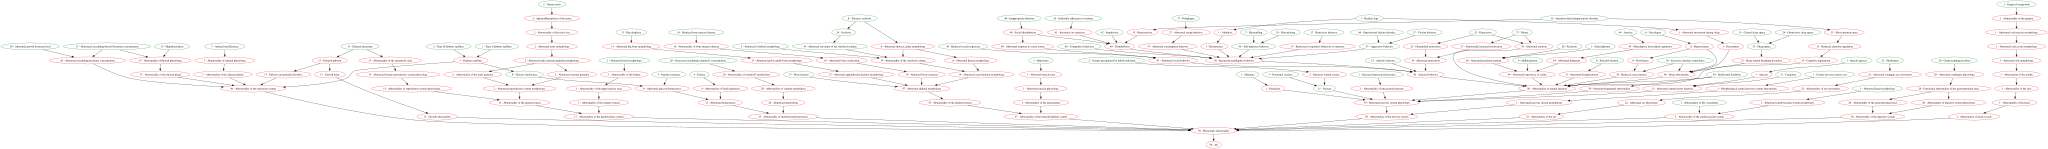

In [5]:
# display the DAG using graphviz with the number of patients per term
hpo_dag_gv

## Phenotypic Similarity

Using the phenotype terms associated with each participant visualize several types of analyses for clustering and inter-participant similarity.

In [6]:
# Cluster the participants based on phenotypes using default settings
from pyhpo.stats import linkage as pyhpo_linkage

lnk = pyhpo_linkage([p["phenotypes"] for p in participants], method="average")
hm_labels = [p["REVISED_GS_MIXED_MDX"] for p in participants]

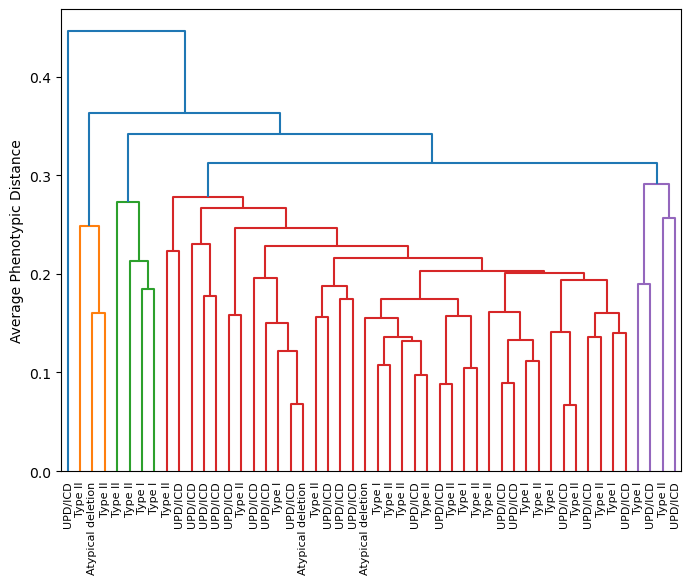

In [7]:
# plot the clustering just using the broader MDx category
plt.figure(figsize=(8, 6))
plt.ylabel('Average Phenotypic Distance')
dendogram_plt = scipy.cluster.hierarchy.dendrogram(lnk, labels=hm_labels)

Convert the hierarchical clustering to an unrooted tree (like in phylogenetics) to see if outliers and cluster are more visually apparent.

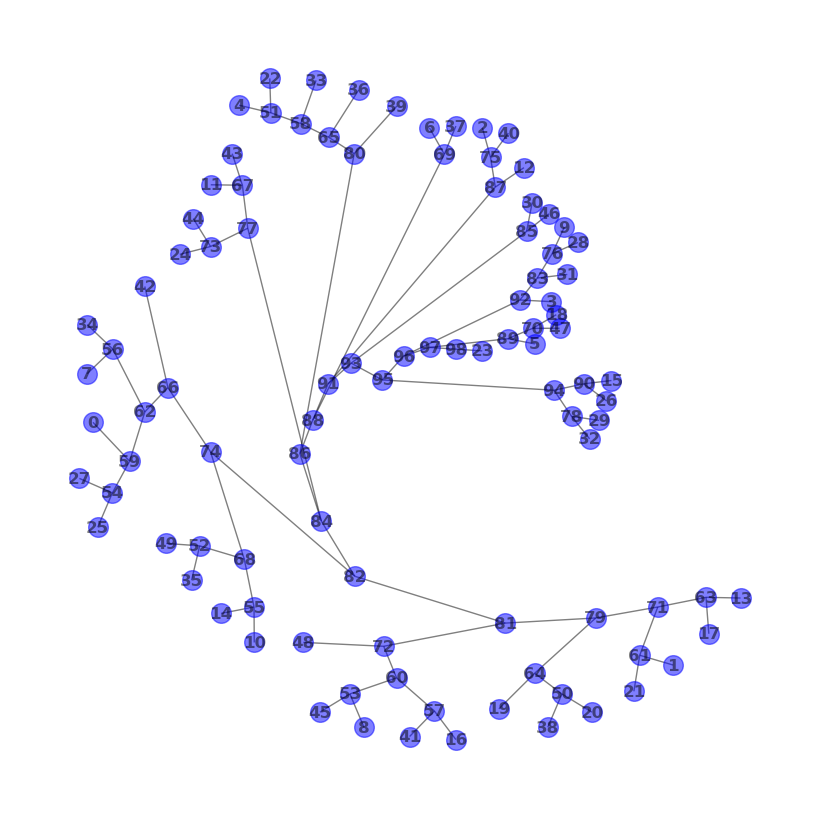

In [8]:
# convert tree to networkx graph
root_node = scipy.cluster.hierarchy.to_tree(lnk)

def traverse_tree(node):
    if node.right.count < 2 and node.left.count < 2:
        # two leaf nodes clustered together
        # yeild edges from each leaf to the cluster node
        yield node.right.id, node.id, {"dist": node.dist}
        yield node.left.id, node.id, {"dist": node.dist}
    elif node.right.count < 2:
        # right node is a leaf node
        yield node.right.id, node.id, {"dist": node.dist}
        yield node.id, node.left.id, {"dist": node.dist - node.left.dist}
        yield from traverse_tree(node.left)
    elif node.left.count < 2:
        # left node is a leaf node
        yield node.left.id, node.id, {"dist": node.dist}
        yield node.id, node.right.id, {"dist": node.dist - node.right.dist}
        yield from traverse_tree(node.right)
    else:
        # left and right nodes are cluster nodes
        yield node.id, node.left.id, {"dist": node.dist - node.left.dist}
        yield node.id, node.right.id, {"dist": node.dist - node.right.dist}
        yield from traverse_tree(node.left)
        yield from traverse_tree(node.right)

nx_tree = nx.Graph()
nx_tree.add_edges_from(list(traverse_tree(root_node)))
pos = nx.nx_agraph.graphviz_layout(nx_tree, prog="twopi", root=root_node.id, args="")
plt.figure(figsize=(8, 8))
nx.draw(
    nx_tree,
    pos,
    node_size=200,
    alpha=0.5,
    node_color="blue",
    with_labels=True,
    font_weight="bold",
)
# plt.axis("equal")
plt.show()

Export the linkage matrix in a format used by phylogenetics programs to plot the unrooted tree using [iTOL: Interactive Tree Of Life](https://itol.embl.de) which has a lot of nice features designed for rendering unrooted trees and customizing the plots with labels.

In [9]:
# convert to a phylogenetic tree and save to file to attempt to work with the data in R instead
from skbio.tree import TreeNode
treenode = TreeNode.from_linkage_matrix(lnk, [p["REVISED_GS_MIXED_MDX"] for p in participants])
treenode.write("../data/processed/pws-pheno-linkage.nwk")

'../data/processed/pws-pheno-linkage.nwk'

## Highest difference defining phenotypes

Similar to using PCA for dimensionality reduction we can use multiple correspondence analysis (MCA) to determine
which categorical factors contribute to the most inertia (variance) in the dataset. We need to account for the
hierarchical structure of the ontology, i.e. include parent terms as being associated with participants. We
need to find the unique set of terms used to describe all participants in the cohort and then denote if
each participant has that phenotype (or a child term of that phenotype) with a boolean value. MCA will
one-hot encode the boolean values and allow us to find the phenotypes most differentiating participants
in the cohort.

In [10]:
# create set of all phenotypes and parent terms
all_terms = set(
    itertools.chain(*[p["all_phenos"] for p in participants])
)

# create dataframe with phenotypes as columns, participants as rows, and boolean cell values
terms_df_data = []
terms_df_columns = []
for term in all_terms:
    terms_df_columns.append(term.id)
    for p_index, participant in enumerate(participants):
        if p_index == len(terms_df_data):
            terms_df_data.append([])
        terms_df_data[p_index].append(term in participant["all_phenos"])

phenos_df = pd.DataFrame(terms_df_data, columns=terms_df_columns, index=hm_labels)

with the data formatted we can fit the MCA model to the phenotype data

In [11]:
mca = prince.MCA(
    n_components=30,
    n_iter=30,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=42,
    correction="benzecri",
)
mca = mca.fit(phenos_df)

With the model fit we can check how much of the variance is attributed to each component

In [12]:
exp_var_cumul = np.cumsum(mca.percentage_of_variance_)

fig = px.area(
    x=range(1, exp_var_cumul.shape[0] + 1),
    y=exp_var_cumul,
    labels={"x": "# Components", "y": "Explained Variance"}
)

fig.update_layout(
    title_text="Cummulative Explained Variance",
    autosize=False,
    height=600,
    width=800,
)

fig.show()

exact percentages are shown below

In [13]:
mca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.009,26.70%,26.70%
1,0.005,14.28%,40.98%
2,0.004,12.45%,53.43%
3,0.003,9.46%,62.89%
4,0.002,6.82%,69.71%
5,0.002,5.76%,75.47%
6,0.001,4.21%,79.68%
7,0.001,3.63%,83.31%
8,0.001,2.78%,86.08%


an interactive plot of the first 2 components with the participants and the one-hot encoded features

In [14]:
mca.plot(phenos_df)

alt.LayerChart(...)

It's clear that we don't need many factors to explain most of the variance in the cohort. There are some
phenotypes seperating out in the first two dimensions but many of them don't. Likewise for participants,
with the exception of the one. Based on the phenotypic (dis)similarity in clustered above one might have
expected to see more of a separation of those same participants. This perhaps indicates that there are
phenotypes that vary between participants but they may not aid in identifying or separating them
pehnotypically.

Though we can pull some generalizations about the phenotypes from the MCA plot we can't/shouldn't use this for
determining which phenotypes are best differentiators of a likely molecular diagnosis.
For this task we can use a support vector classifier and feature elimination method to arive at the smallest set of
MDx category predictive phenotypes (features) to use for quantitatively differentiating participants per
MDx category.

In [15]:
# create traget MDx category dataset for accuracy calc
p_mdx_class = pd.Series(name="GS MDx Category", data=[p["GS_CATEGORY"] for p in participants])
# create target broad MDx category for accuracy calc
p_broad_mdx_class = pd.Series(name="Broad MDx Category", data=[p["broad_cat"] for p in participants])
p_simple_mdx_class = pd.Series(name="Simple MDx Category", data=[p["GENERIC_REVISED_GS_SUB_CAT"] for p in participants])

Compute the cross-validated SVC model for both the 4 category and broader 3 category MDx'

In [16]:
min_features_to_select = 1  # Minimum number of features to consider
clf = LinearSVC(random_state=42, tol=1e-5, max_iter=100000) # recommended for data type and size
cv = StratifiedKFold(4)

rfecv = RFECV(
    estimator=clf,
    step=1,
    cv=cv,
    scoring="accuracy",
    min_features_to_select=min_features_to_select,
    n_jobs=2,
)
rfecv.fit(phenos_df, p_mdx_class)

print(f"4 category MDx optimal number of features: {rfecv.n_features_}")

clf = LinearSVC(random_state=42, tol=1e-5, max_iter=100000) # recommended for data type and size
cv = StratifiedKFold(4)

b_rfecv = RFECV(
    estimator=clf,
    step=1,
    cv=cv,
    scoring="accuracy",
    min_features_to_select=min_features_to_select,
    n_jobs=2,
)
b_rfecv.fit(phenos_df, p_broad_mdx_class)

print(f"Broader 3 category MDx optimal number of features: {b_rfecv.n_features_}")

clf = LinearSVC(random_state=42, tol=1e-5, max_iter=100000) # recommended for data type and size
cv = StratifiedKFold(4)

simple_rfecv = RFECV(
    estimator=clf,
    step=1,
    cv=cv,
    scoring="accuracy",
    min_features_to_select=min_features_to_select,
    n_jobs=2,
)
simple_rfecv.fit(phenos_df, p_simple_mdx_class)

print(f"Revised Simplified 3 category MDx optimal number of features: {simple_rfecv.n_features_}")

4 category MDx optimal number of features: 1
Broader 3 category MDx optimal number of features: 11


/Users/brandon/miniforge3/envs/pws-pheno/lib/python3.11/site-packages/sklearn/model_selection/_split.py:813: UserWarning:

The least populated class in y has only 1 members, which is less than n_splits=4.



Revised Simplified 3 category MDx optimal number of features: 2


let's double check the optimization looking at the change in accuracy of predictions with each iteration

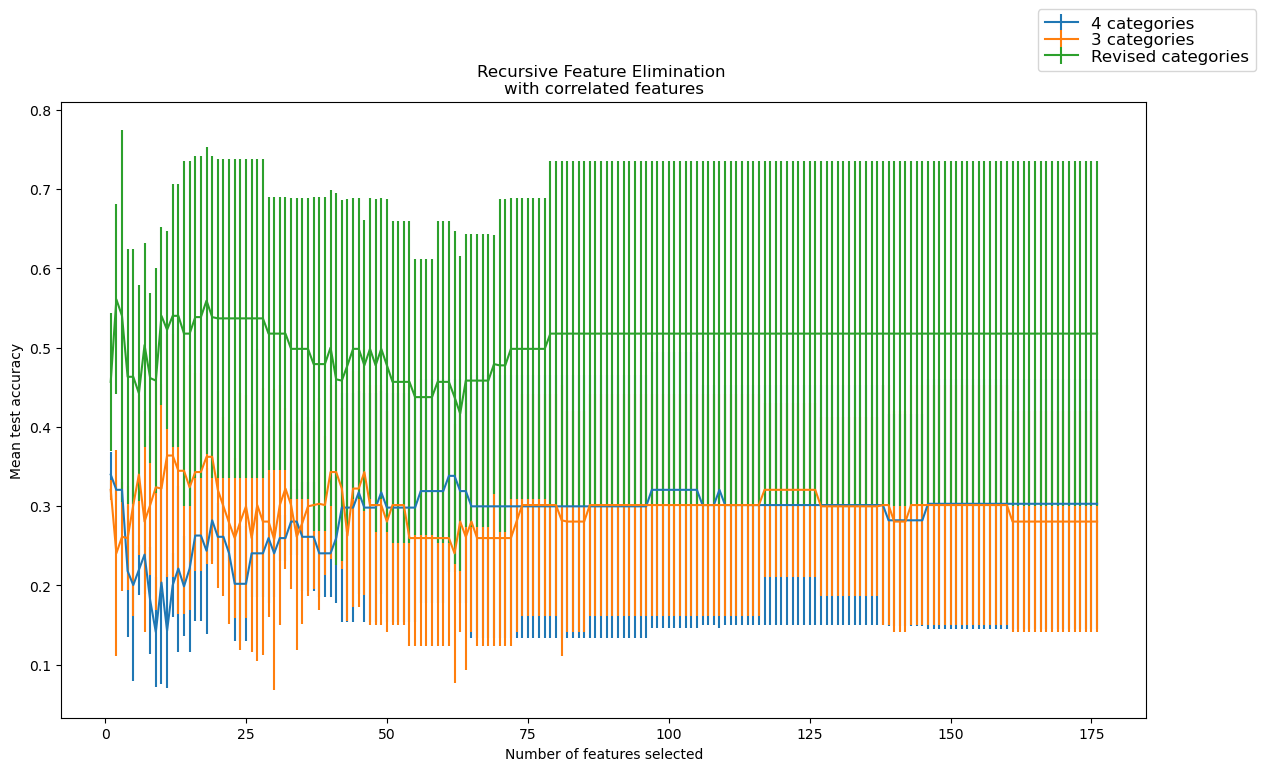

In [17]:
cv_results = pd.DataFrame({
    key: value
    for key, value in rfecv.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
})
b_cv_results = pd.DataFrame({
    key: value
    for key, value in b_rfecv.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
})
simple_cv_results = pd.DataFrame({
    key: value
    for key, value in simple_rfecv.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
})
plt.figure(figsize=(14,8))
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.errorbar(
    x=b_cv_results["n_features"],
    y=b_cv_results["mean_test_score"],
    yerr=b_cv_results["std_test_score"],
)
plt.errorbar(
    x=simple_cv_results["n_features"],
    y=simple_cv_results["mean_test_score"],
    yerr=simple_cv_results["std_test_score"],
)
plt.legend(["4 categories", "3 categories", "Revised categories"], loc=(0.9, 1.05), labelspacing=0.1, fontsize="large")
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

In [18]:
simple_rfecv.get_feature_names_out()

array(['HP:0010865', 'HP:0012167'], dtype=object)

Like the MCA model we see that a few phenotypes have some predictive value in the SVC model, moreso when there are 3 categories to choose from. This analysis does not optimize the SVCs for hyperparameters, it only provides a view for determining if there are strong phenotypes that differentiate by MDx category. From this rough analysis it doesn't appear that there is a small subset of phenotypes with predictive enough power to differentiate. This is ok b/c this modeling doesn't account for confounding environmental factors (e.g. home environment, parental involvment, age/development, etc.) by design.

## Matrix plot of continuous variables and metadata

We can see if any of the metadata would help identify clusters or outliers.

In [21]:
# create dataframe with only meta data loaded
meta_df = pd.DataFrame(participants, index=hm_labels, columns=["AGE","SEX","BMI","HQCT","PADQ","REVISED_GS_MIXED_MDX"])
for col in ["AGE","BMI","HQCT","PADQ"]:
    meta_df[col] = meta_df[col].astype(float)

# sort by subtype for plotting
meta_df.sort_values(by="REVISED_GS_MIXED_MDX", inplace=True)
meta_df.rename(columns={"REVISED_GS_MIXED_MDX":"PWS Subtype"}, inplace=True)

Now we can plot all the metadata features to get a sense of how they look relative to each other using a Pairplot. Each datapoint on the plot corresponds to a participant in the cohort colored by their MDx category. Like we saw in previious analyses, there isn't an obvious pattern corresponding to the MDx. Looking at the distributions of values for each piece of metadata, the diagonals in the plot, it's clear that the PADQ and HQCT discriminate by MDx, somewhat, but have clear overlap. Instead we can reduce this to 2 new features via PCA and see if any seperation occurs there.

/Users/brandon/miniforge3/envs/pws-pheno/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/brandon/miniforge3/envs/pws-pheno/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/brandon/miniforge3/envs/pws-pheno/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/brandon/miniforge3/envs/pws-pheno/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with 

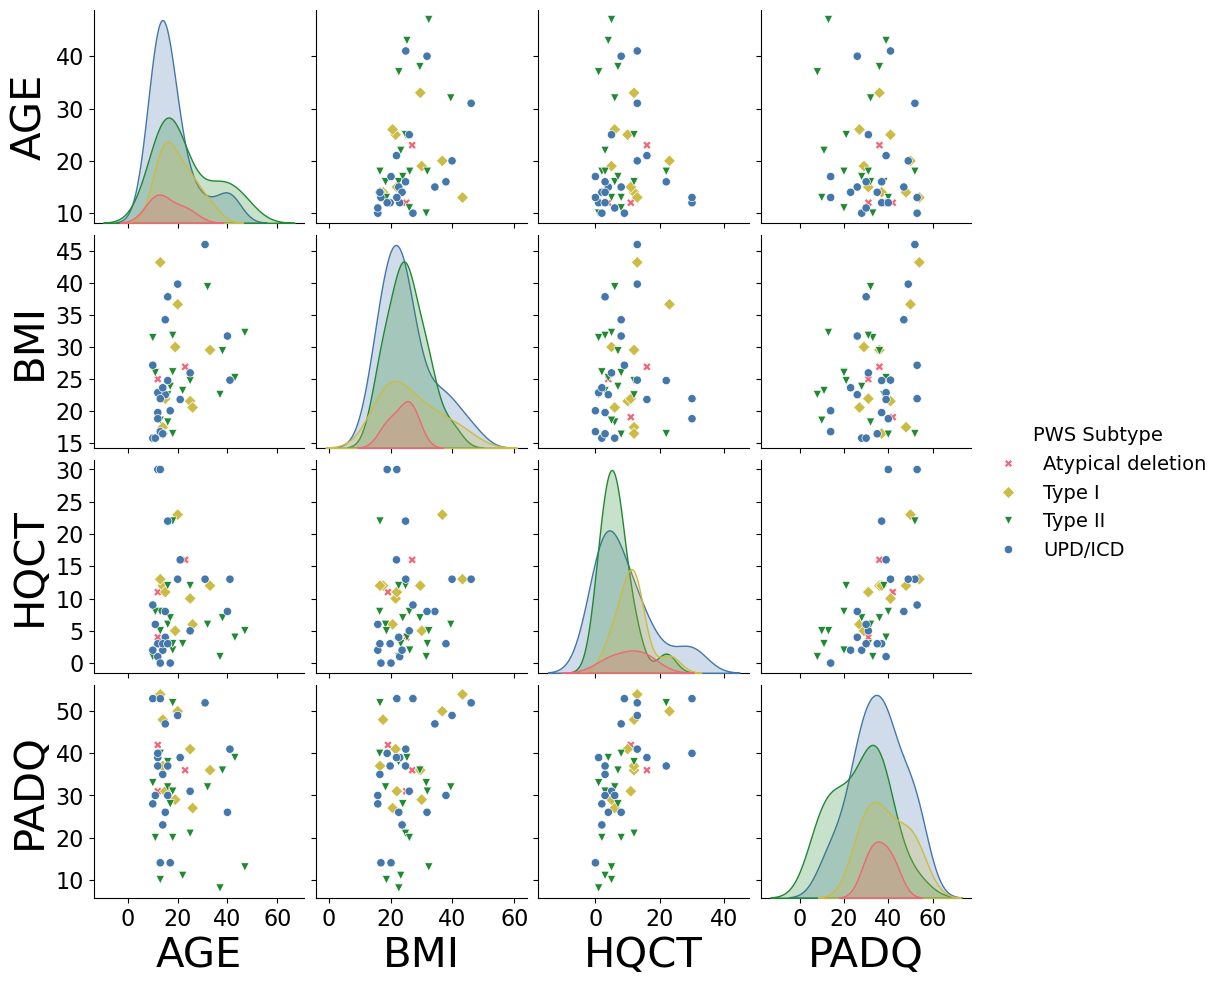

In [22]:
with sns.plotting_context(rc={"axes.labelsize":30, "xtick.labelsize": 16, "ytick.labelsize": 16, "legend.fontsize": 14, "legend.title_fontsize": 14}):
    sns_plot = sns.pairplot(meta_df, hue="PWS Subtype", palette=cohort_color_pallet.getCategoryColorPalletHex(), markers=["X", "D", "v", "o"])
    sns_plot.figure.savefig("../data/processed/metadata-scatter-mtrix.png", dpi=300)

## Radar plots of reduced phenotype lists

We can now plot the phenotypic differences between MDx categories quantitatively (with the computed list of most differentiating phenotypes)
and qualitatively (using a method of selectively using parent terms determined by hand).

In [25]:
# HPOSet doesn't maintaint order defined in list so
# list comprehension is used to maintain desired order
qual_pheno_terms = [
    Ontology.hpo(hpo_id)
    for hpo_id in [
        5200275,  # abnormal motivation
        716,  # depression
        31589,  # suicidal ideation
        718,  # aggressive behavior, encapsulates aggression, oppositional def. dis., and violent behav.
        100716,  # self-injurious behavior
        722,  # compulsive behavior
        5200283,  # sleep-related breathing disorders
        1262,  # excessive daytime somnolence
        1250,  # Seizures
        2591,  # polyphagia
        100710,  # impulsivity
        732,  # inflexible adherence to routines
        7018,  # ADHD
        31432,  # restricted or reptative behaviors or interests
        738,  # hallucinations
        5200430,  # abn. psychotic pattern
        1626,  # abn. of the cardio system
        11442,  # Abn. central motor function
        2020,  # gastroesophageal reflux
        486,  # strabismus
        969,  # edema
        100512,  # decreased circulating vitamin D
        11014,  # abn. glucose homeostatsis
        78,  # abn. of the genital system
        32367,  # abn. growth hormone level
        820,  # abn. of the thyroid gland
        834,  # abn. of the adrenal glands
        925,  # abn. of the vertebral column
        1385,  # hip dysplasia
        4349,  # reduced bone mineral density
        20110,  # bone fracture
    ]
]

# create a list of terms to rollup to, based on the following criteria:
#  1) at least 10% of cohort have the term (or rollup to it)
#  2) it's a leaf term (i.e. no children terms after filter stage 1) reported in at least 1 participant
#     where none of its direct or indirect parent terms are reported in any participants  
#  3) it's the shallowest term reported in at least 1 participant in the DAG following removal of
#     terms by filters 1 and 2
cnt_filt_terms = {term for term, rollup_cnt in term_counts.items() if rollup_cnt > 4}
leaf_terms = {term for term in cnt_filt_terms if cnt_filt_terms.isdisjoint(term.children)}
no_parent_leaf_terms = {term for term in leaf_terms if term.all_parents.isdisjoint(directly_phenotyped_terms)}

visualize the DAG after pruning the leaf terms and their direct and indirect parents to see what is left

In [26]:
# Create the DAG
pruned_hpo_dag_gv = graphviz.Digraph("Pruned Phenotype DAG")

# get set of count passing terms that aren't leaf terms
leftover_terms = leaf_terms - no_parent_leaf_terms
for term in leftover_terms:
    leftover_terms = leftover_terms.union(term.all_parents)

# add nodes to the graph with coloring based on directly phenotyped in a participant or not
for term in leftover_terms:
    pruned_hpo_dag_gv.node(term.id.replace(":","_"), f"{term_counts[term]} - {term.name}", color="green" if term in directly_phenotyped_terms else "red")

# add edges to the graph
for term in leftover_terms:
    for parent in term.parents:
        pruned_hpo_dag_gv.edge(term.id.replace(":","_"), parent.id.replace(":","_"))

show the DAG

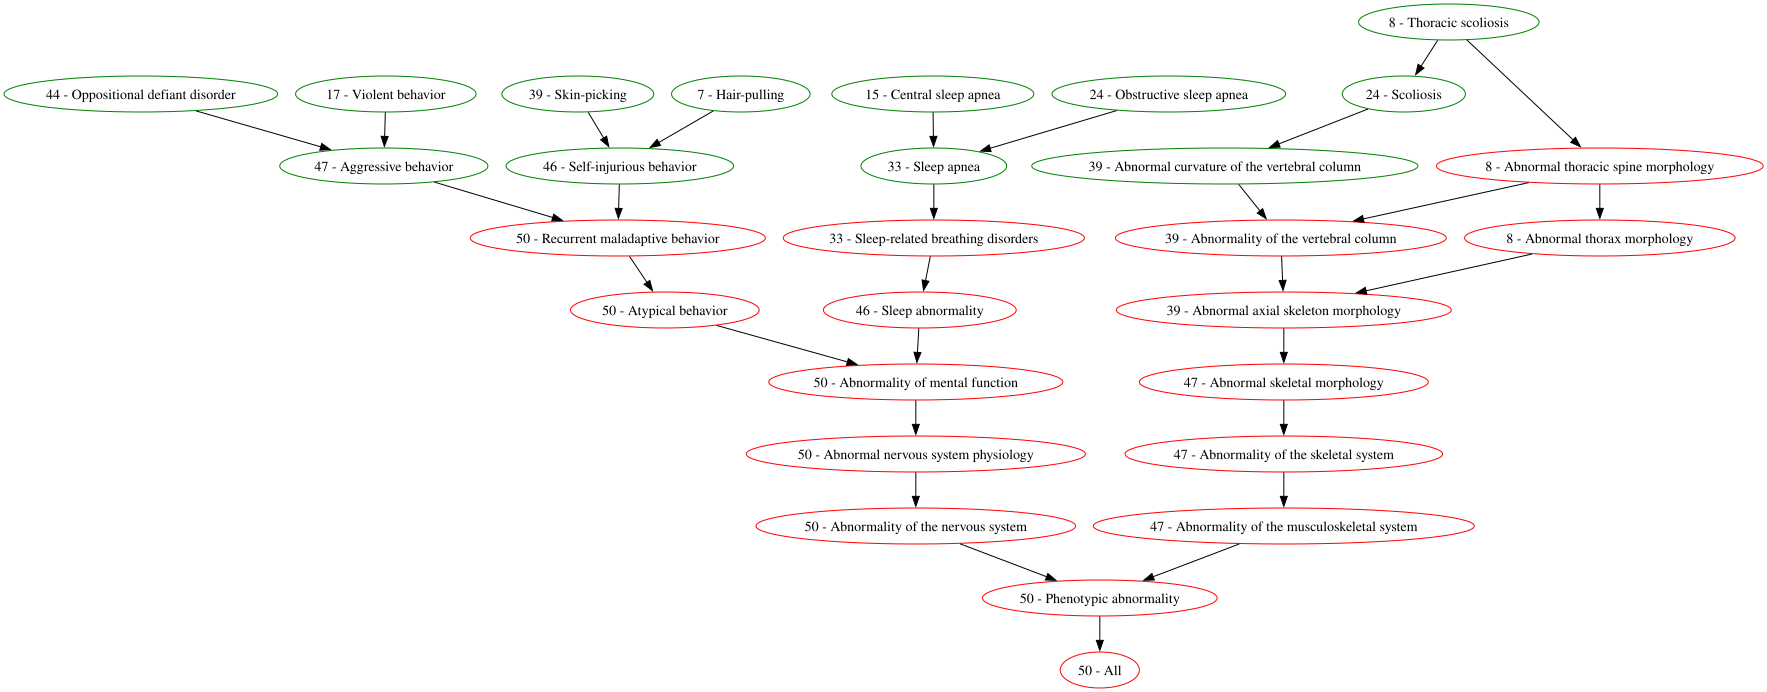

In [27]:
pruned_hpo_dag_gv

In [28]:
directly_phenotyped_leftover_terms = leftover_terms.intersection(directly_phenotyped_terms)
shallowest_leftover_terms = {term for term in directly_phenotyped_leftover_terms if term.all_parents.isdisjoint(directly_phenotyped_leftover_terms)}

algorithmic_filtered_rollup_terms = no_parent_leaf_terms.union(shallowest_leftover_terms)
print(f"Algorithmic phenotype roll up terms found: {len(algorithmic_filtered_rollup_terms)}")
print("Part. Cnt.\tPhenotype")
for term in algorithmic_filtered_rollup_terms:
    print(f"{term_counts[term]}\t{term.name}")

Algorithmic phenotype roll up terms found: 38
Part. Cnt.	Phenotype
5	Abnormal vertebral morphology
17	Bone fracture
37	Mania
17	Abnormal circulating thyroid hormone concentration
13	Delayed menarche
37	Polyphagia
20	Decreased circulating vitamin D concentration
8	Glucose intolerance
33	Sleep apnea
39	Abnormal curvature of the vertebral column
15	Hypothyroidism
28	Psychosis
25	Depression
7	Adrenal insufficiency
40	Inappropriate behavior
47	Aggressive behavior
48	Compulsive behaviors
17	Restrictive behavior
5	Insulin resistance
30	Reduced social reciprocity
12	Autistic behavior
41	Inflexible adherence to routines
11	Cataplexy
50	Intellectual disability
9	Hallucinations
44	Anxiety
11	Seizure
8	Narcolepsy
8	Suicidal ideation
42	Impulsivity
20	Gastroesophageal reflux
13	Hip dysplasia
15	Attention deficit hyperactivity disorder
22	Strabismus
46	Self-injurious behavior
38	Excessive daytime somnolence
38	Abnormal growth hormone level
10	Reduced bone mineral density


In [ ]:
def topological_pheno_sort(pheno_terms):
    pheno_graph = nx.DiGraph()
    all_nodes = {pterm for term in pheno_terms for pterm in term.all_parents}
    all_nodes = all_nodes.union(pheno_terms)
    # add phenotype terms, direct parents, and indirect parents as nodes to the graph
    pheno_graph.add_nodes_from(all_nodes)
    # add edges from term to parent terms
    for term in all_nodes:
        pheno_graph.add_edges_from((term, pterm) for pterm in term.parents)
    sorted_nodes = list(nx.topological_sort(pheno_graph))
    pheno_terms = list(pheno_terms)
    pheno_terms.sort(key=lambda term: sorted_nodes.index(term))
    return pheno_terms


def similarity_pheno_sort(pheno_terms, sorted_phenos=None):
    if not sorted_phenos:
        sorted_phenos = []
        pheno_terms = sorted(pheno_terms, key=lambda t: t.shortest_path_to_root())
        sorted_phenos.append(pheno_terms.pop())

    if len(pheno_terms) > 0:
        sim_scores = sorted_phenos[-1].similarity_scores(pheno_terms, method="dist")
        max_sim_score = max(sim_scores)
        sorted_phenos.append(pheno_terms.pop(sim_scores.index(max_sim_score)))
    else:
        return sorted_phenos

    return similarity_pheno_sort(pheno_terms, sorted_phenos)


# convert hex colors to rgba for opacity info
def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.replace("#", "")
    return f"rgba({int(hex_color[0:2], 16)},{int(hex_color[2:4], 16)},{int(hex_color[4:6], 16)},{alpha})"


def rollup_participant_phenos(
    participants, spoke_terms=qual_pheno_terms, category_key="GS_CATEGORY"
):
    # define labels for each spoke used in chart
    labels = [term.name for term in spoke_terms]

    # get count of participants with each spoke term by each MDx category
    mdx_count = Counter(
        (p[category_key], term)
        for p in participants
        for term in p["all_phenos"]
        if term in spoke_terms
    )

    # convert counts to percentage of participants in each MDx category
    mdx_cat_cnt = Counter(p[category_key] for p in participants)
    norm_ret_data = {}
    for mol_cat in mdx_cat_cnt.keys():
        norm_ret_data[mol_cat] = []
        # append numerical data in same order per category
        for term in spoke_terms:
            norm_ret_data[mol_cat].append(
                (float(mdx_count[(mol_cat, term)]) / float(mdx_cat_cnt[mol_cat]))
                * 100.0
            )

    return labels, norm_ret_data


def individual_plot_radar(
    fig_title,
    spoke_labels,
    data_points,
    color,
    figsize=(1000, 1000),
    spoke_label_size=12,
    label_angle=0,
    file_path=None,
):
    fig = go.Figure()
    trace = go.Scatterpolar(
        r=data_points,
        theta=spoke_labels,
        fill="toself",
        fillcolor=hex_to_rgba(color, 0.25),
        line=dict(color=color),
    )
    fig.add_trace(trace)

    polar_plot_axis_settings = dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100],
            angle=90,
            tickangle=90 + label_angle,
            tickfont=dict(size=spoke_label_size),
        ),
        angularaxis=dict(tickfont=dict(size=spoke_label_size), tickangle=label_angle),
    )
    fig.update_layout(
        autosize=False,
        title_text=fig_title,
        title_x=0.5,
        height=figsize[0],
        width=figsize[1],
        polar=polar_plot_axis_settings,
    )
    if file_path:
        fig.write_image(file_path, height=figsize[0], width=figsize[1])
    else:
        fig.show()


def single_multi_plot_radar(
    fig_title,
    categories,
    spoke_labels,
    data_points_per_cat,
    n_cohort,
    colors,
    figsize=(1000, 1000),
    spoke_label_size=12,
    label_angle=0,
    file_path=None,
):
    fig = go.Figure()
    for mol_cat in sorted(categories):
        trace = go.Scatterpolar(
            r=data_points_per_cat[mol_cat],
            theta=spoke_labels,
            fill="toself",
            fillcolor=hex_to_rgba(colors[mol_cat], 0.25),
            name=f"{mol_cat} (N={str(n_cohort[mol_cat])})",
            line=dict(color=colors[mol_cat]),
        )
        fig.add_trace(trace)

    polar_plot_axis_settings = dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100],
            angle=90,
            tickangle=90 + label_angle,
            tickfont=dict(size=spoke_label_size),
        ),
        angularaxis=dict(tickfont=dict(size=spoke_label_size), tickangle=label_angle),
    )
    fig.update_layout(
        autosize=False,
        height=figsize[0],
        width=figsize[1],
        polar=polar_plot_axis_settings,
    )
    if fig_title:
        fig.update_layout(
            title_text=fig_title,
            title_x=0.5,
        )
    if file_path:
        fig.write_image(file_path, height=figsize[0], width=figsize[1])
    else:
        fig.show()


def plot_radar(
    spoke_labels,
    data_per_cat,
    colors,
    figsize=(1200, 1200),
    single=True,
    spoke_label_size=10,
):
    # sort dictionary of categories by keys
    data_per_cat = {key: data_per_cat[key] for key in sorted(data_per_cat.keys())}
    n_cohort = (
        Counter(p["GS_CATEGORY"] for p in participants)
        if len(data_per_cat) == 4
        else Counter(p["broad_cat"] for p in participants)
    )
    subplot_titles = list(
        f"{mol_cat} (N={str(n_cohort[mol_cat])})" for mol_cat in data_per_cat.keys()
    )
    if len(data_per_cat) == 3:
        subplot_titles.append("All MDx (N=50)")

    fig = (
        go.Figure()
        if single
        else make_subplots(
            rows=2,
            cols=2,
            specs=[
                [{"type": "polar"}, {"type": "polar"}],
                [{"type": "polar"}, {"type": "polar"}],
            ],
            subplot_titles=subplot_titles,
            vertical_spacing=0.05,
        )
    )

    for cat_idx, (mol_cat, pheno_cnts) in enumerate(data_per_cat.items()):
        trace = go.Scatterpolar(
            r=pheno_cnts,
            theta=spoke_labels,
            fill="toself",
            fillcolor=hex_to_rgba(colors[mol_cat], 0.25),
            name=f"{mol_cat} (N={str(n_cohort[mol_cat])})",
            line=dict(color=colors[mol_cat]),
        )
        if single:
            fig.add_trace(trace)
        else:
            fig.add_trace(trace, row=1 + int(cat_idx / 2), col=1 + cat_idx % 2)

    # if plotting only 3 MDx categories make the fourth plot a collection of overlapping plots
    if not single and len(data_per_cat) == 3:
        for mol_cat, pheno_cnts in data_per_cat.items():
            fig.add_trace(
                go.Scatterpolar(
                    r=pheno_cnts,
                    theta=spoke_labels,
                    fill="toself",
                    fillcolor=hex_to_rgba(colors[mol_cat], 0.25),
                    name=f"{mol_cat} (N={str(n_cohort[mol_cat])})",
                    line=dict(color=colors[mol_cat]),
                ),
                row=2,
                col=2,
            )

    polar_plot_axis_settings = dict(
        radialaxis=dict(visible=True, range=[0, 100], angle=90, tickangle=90),
        angularaxis=dict(tickfont=dict(size=spoke_label_size)),
    )
    if single:
        fig.update_layout(
            autosize=False,
            height=figsize[0],
            width=figsize[1],
            polar=polar_plot_axis_settings,
        )
    else:
        fig.update_layout(
            autosize=False,
            height=figsize[0],
            width=figsize[1],
            polar=polar_plot_axis_settings,
            polar2=polar_plot_axis_settings,
            polar3=polar_plot_axis_settings,
            polar4=polar_plot_axis_settings,
        )

    fig.show()

### Radar Plot: Qualitatively selected roll up phenotypes

Phenotype terms for roll up were manually determined by inspecting the subset of terms from the HPO ontology
found within the cohort plotted as a DAG and overlayed with participant counts of terms found within the cohort.

#### Modified Deletion vs UPD/Epimutation/IC Defect phenotype comparison

Many in the PWS community would seek to see the phenotype differences between the large deletion cases and those with UPD, Epimutations, or IC defects.

In [34]:
def clean_labels(labels):
    clean_labels = []
    for label in labels:
        clean_label = (
            label.replace("-<br>", "")
            .replace("<br>", " ")
            .replace(" or ", "/")
            .replace("&nbsp;", "")
        )
        if (
            clean_label == "Suicidal ideation"
            or clean_label.startswith("Excessive")
        ):
            clean_label = "<br>" + clean_label
        if clean_label.startswith("Sleep-related"):
            clean_label = "<br><br>" + clean_label
        if (
            clean_label == "Seizure"
            or clean_label.startswith("Abnormal central")
            or clean_label == "Depression"
        ):
            clean_label = clean_label + "<br>"
        clean_labels.append(clean_label)

    return clean_labels

In [ ]:
# filter out the participant with a translocation and then plot the phenotype diagrams
import re

filt_participants = list(
    filter(lambda p: p["GENERIC_REVISED_GS_SUB_CAT"] != "Deletion*", participants)
)

for cat_col in ["GENERIC_REVISED_GS_SUB_CAT", "REVISED_GS_MIXED_MDX"]:
    spoke_labels, data_points = rollup_participant_phenos(
        filt_participants,
        spoke_terms=similarity_pheno_sort(qual_pheno_terms),
        category_key=cat_col,
    )

    upd_mol_cat_cnt = {}
    for p in filt_participants:
        mol_cat = p[cat_col]
        if mol_cat not in upd_mol_cat_cnt:
            upd_mol_cat_cnt[mol_cat] = 0
        upd_mol_cat_cnt[mol_cat] += 1

    # add starting point as extra data point to trick edgeline to close the path
    spoke_labels = clean_labels(spoke_labels)
    spoke_labels.append(spoke_labels[0])
    for data_point_list in data_points.values():
        data_point_list.append(data_point_list[0])

    for molecular_category, cat_cnt in upd_mol_cat_cnt.items():
        save_pdf = f"../data/processed/GS-general-mdx-{re.sub(r'[ /,]+','-',molecular_category)}-qualitative-pheno-radar.pdf"
        if cat_col == "REVISED_GS_MIXED_MDX":
            save_pdf = f"../data/processed/GS-mixed-mdx-{re.sub(r'[ /,]+','-',molecular_category)}-qualitative-pheno-radar.pdf"

        data = list(data_points[molecular_category])
        # add 1 point again to clost the border around the plot (not sure why this doesn't happen automatically)
        data.append(data[0])
        individual_plot_radar(
            f"{molecular_category} (N={cat_cnt})",
            spoke_labels,
            data,
            cohort_color_pallet.getCategoryColorHex(molecular_category),
            figsize=(600, 1070),
            spoke_label_size=14,
            file_path=save_pdf,
        )

    single_multi_plot_radar(
        None,
        upd_mol_cat_cnt.keys(),
        spoke_labels,
        data_points,
        upd_mol_cat_cnt,
        cohort_color_pallet.getCategoryColorPalletHex(),
        figsize=(600, 1190),
        spoke_label_size=14,
        file_path=(
            "../data/processed/GS-mixed-mdx-qualitative-pheno-radar.pdf"
            if cat_col == "REVISED_GS_MIXED_MDX"
            else "../data/processed/GS-general-mdx-qualitative-pheno-radar.pdf"
        ),
    )

#### Stats using Fisher's exact

determine if there are any statistically significantly different phenotypes between subtypes.

In [37]:
from scipy.stats import fisher_exact
from scipy.stats import false_discovery_control
from scipy.stats import MonteCarloMethod

# perform exact test using approximation via Monte Carlo simulations when more than 2 categories
rng = np.random.default_rng()
mc_method = MonteCarloMethod(rng=rng)

for cat_col in ["GENERIC_REVISED_GS_SUB_CAT", "REVISED_GS_MIXED_MDX"]:
    spoke_labels, data_points = rollup_participant_phenos(
        filt_participants,
        spoke_terms=similarity_pheno_sort(qual_pheno_terms),
        category_key=cat_col,
    )
    # clean up phenotype labels for better printing
    spoke_labels = clean_labels(spoke_labels)

    n_in_cohort = Counter(p[cat_col] for p in filt_participants)
    pheno_fe_test = []
    for idx, label in enumerate(spoke_labels):
        contin_matrix = []
        for subtype in n_in_cohort.keys():
            subtype_fe_p = round(
                float(n_in_cohort[subtype]) * data_points[subtype][idx] / 100.0
            )
            subtype_fe_np = n_in_cohort[subtype] - subtype_fe_p
            contin_matrix.append([subtype_fe_p, subtype_fe_np])
        if len(n_in_cohort.keys()) > 2:
            test_res = fisher_exact(contin_matrix, method=mc_method)
        else:
            test_res = fisher_exact(contin_matrix)
        pheno_fe_test.append(
            {
                "comparison": cat_col,
                "pheno": label,
                "p-value": test_res.pvalue,
            }
        )

    # apply Benjamini-Hochberg Procedure to adjust for multiple hypothesis testing
    adj_pvals = false_discovery_control(
        [test_info["p-value"] for test_info in pheno_fe_test]
    )
    for raw_test_info, adj_p in zip(pheno_fe_test, adj_pvals):
        raw_test_info["adj. p-value"] = adj_p
    output_df = pd.DataFrame(pheno_fe_test)
    outpath = f"../data/processed/{cat_col}_pheno_stats.csv"
    output_df.to_csv(outpath, index=False)
    print(f"Stats written to {outpath}")

Stats written to ../data/processed/GENERIC_REVISED_GS_SUB_CAT_pheno_stats.csv
Stats written to ../data/processed/REVISED_GS_MIXED_MDX_pheno_stats.csv
